<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/AnalisisTexto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de texto

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 24 de febrero de 2026




**Actividad:**
* Analice el siguiente texto y aplique las técnicas de PLN que crea necesarias (nube de palabras, gráficas, lemas, stopwords, limpieza, etc.).
* Instale las librerías necesarias.
* Desarrolle su script de Python implementando el código en funciones.
* Describa el efecto de las técnicas utilizadas al ser aplicadas al texto al ser procesado.

```
En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.
@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.
Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.
El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital
Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos.
```



### Instalar librería Stanza

In [5]:
!pip install stanza

### Importar librerías que se van a utilizar

In [52]:
import re
import matplotlib.pyplot as plt
import nltk
import stanza
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
stanza.download('es')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Texto seleccionado

In [34]:
texto = """
En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.
@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.
Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.
El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital
Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos."""

### Función para normalizar texto

In [33]:
def normalizar(texto):
  # Hacer todas las letras minúsculas
  texto = texto.lower()

  # Elimina URLs
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

  # Elimina correos electrónicos
  texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto)

  # Elimina menciones (@usuario)
  texto = re.sub(r'@\w+', '', texto)

  # Elimina hashtags completos
  texto = re.sub(r'#\w+', '', texto)

  # Elimina todo lo que no son letras, números o espacios
  texto = re.sub(r'[^\w\s]', '', texto)

  # Elimina espacios múltiples y saltos de línea extra
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

### Función para lematizar

In [54]:
nlp = stanza.Pipeline(
    lang='es',
    processors='tokenize,mwt,pos,lemma',
    use_gpu=False,
    verbose=False
)

def lematizar(texto):
  doc = nlp(texto)

  lista_lemas = []
  for sentence in doc.sentences:
      for word in sentence.words:
          lista_lemas.append(word.lemma)

  return lista_lemas

### Función para eliminar *stopwords*

In [55]:
def eliminar_stopwords(lista):
  stop_words = set(stopwords.words('spanish'))

  lista_limpia = [palabra for palabra in lista if palabra not in stop_words and len(palabra) > 2]
  return lista_limpia

### Función para crear una gráfica con las 20 palabras más usadas


In [56]:
def graficar_resultados(lista_palabras, color_barra):

  counter = Counter(lista_palabras)
  most_common = counter.most_common(20)
  print(most_common)

  palabras, frecuencias = zip(*most_common)

  sns.set_style('whitegrid')
  plt.figure(figsize=(14, 7))


  sns.barplot(x=list(palabras), y=list(frecuencias), color=color_barra)

  plt.xlabel('Palabras')
  plt.xticks(rotation=45)
  plt.ylabel('Frecuencia')
  plt.title('20 palabras más usadas')
  plt.tight_layout()
  plt.show()

### Función para crear una nube de palabras

In [57]:
def nube_palabras(lista_palabras, color_nube):
  frecuencias = dict(Counter(lista_palabras))

  wc = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=color_nube,
      random_state = 12
  ).generate_from_frequencies(frecuencias)
  plt.figure(figsize=(10, 5))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title('Nube de palabras')
  plt.show()

In [59]:
def ejecutar_version(funcion_normalizar, color_barra, color_nube):
      # Normalizar
      texto_normalizado = funcion_normalizar(texto)

      # Lemizar
      texto_lista = lematizar(texto_normalizado)

      # Eliminar stopwords
      texto_limpio = eliminar_stopwords(texto_lista)

      graficar_resultados(texto_limpio, color_barra)
      nube_palabras(texto_limpio, color_nube)

# Mostrar resultados

[('inteligencia', 4), ('artificial', 4), ('congreso', 1), ('internacional', 1), ('2025', 1), ('discutir', 1), ('avance', 1), ('importante', 1), ('comentar', 1), ('ética', 1), ('deber', 1), ('siempre', 1), ('centro', 1), ('investigación', 1), ('poder', 1), ('leer', 1), ('enviar', 1), ('duda', 1), ('correo', 1), ('pérez', 1)]


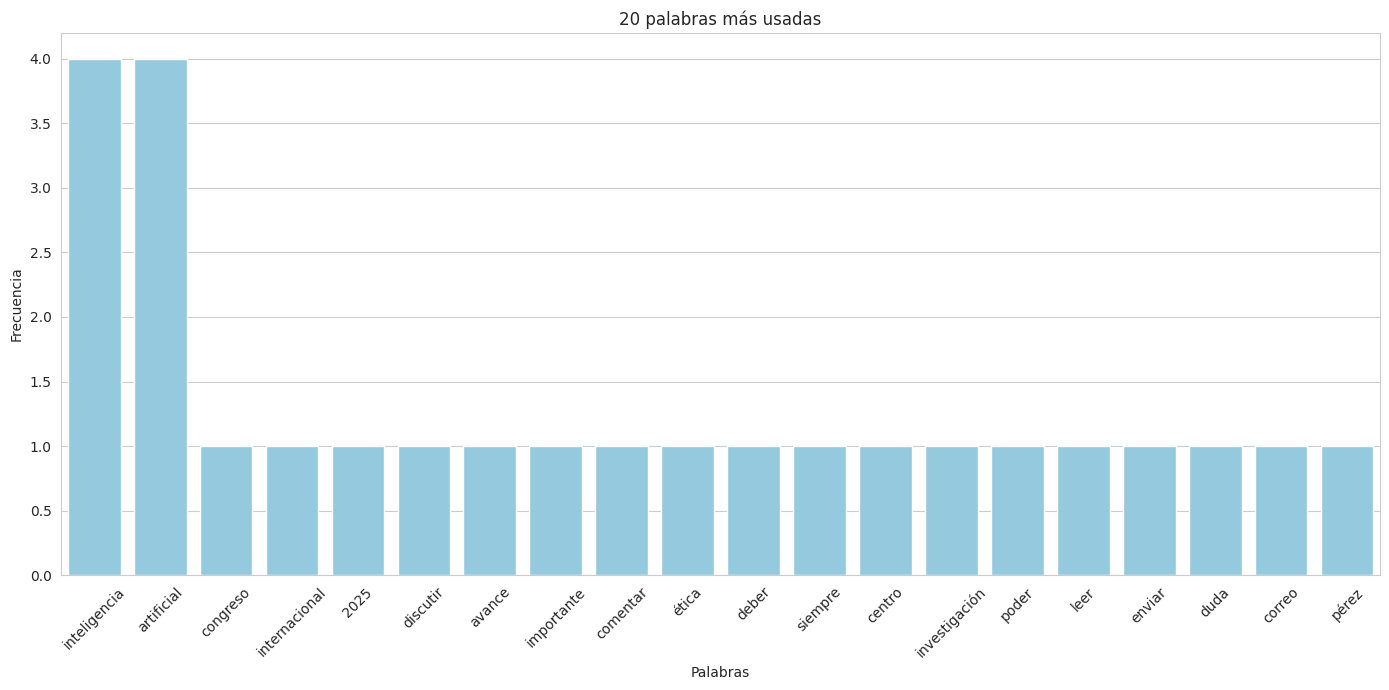

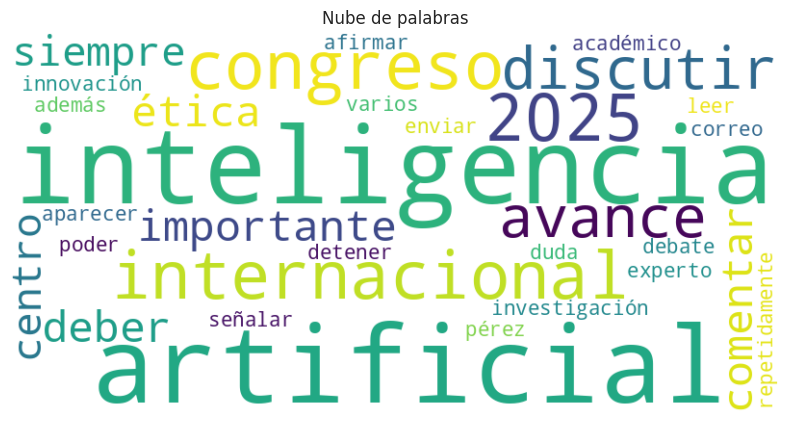

In [60]:
ejecutar_version(normalizar,
                 "skyblue",
                 "viridis")

**Conclusiones.** En este ejercicio, debido a que el texto no es muy grande no hubo necesidad de probar con los hashtags si se debían quitar completos o solo eliminar el símbolo `#`. Además, no se usó ningún tratamiento para emojis. Por otro lado, Stanza no une palabras como Inteligencia Artificial cuyo concepto considero que debería estar ligado. Aunque preferí mantener esta separación para el caso de que visualmente no fuera capaz de ver la palabra "inteligencia" usada en otro contexto, lo cual fue aclarado en la gráfica de barras.